In [50]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pickle
import globals as gl
import pandas as pd

plt.style.use('default')

In [51]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp']
epochs = ['Pre', 'SLR', 'LLR', 'Vol']
H = 'L'
freqs = ['alpha', 'beta', 'gamma']
time_interval = ['early', 'late']
experiment1 = 'smp0'
experiment2 = 'smp2'

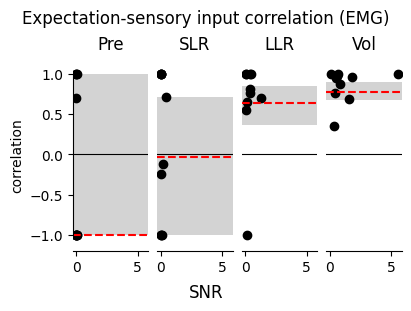

In [52]:
df_corr_emg = pd.read_csv(os.path.join(gl.baseDir, experiment1, gl.pcmDir, 'correlations.EMG.tsv'), sep='\t')

fig, axs = plt.subplots(1, len(epochs), sharex=True, sharey=True, figsize=(4, 3), constrained_layout=True)

for e, epoch in enumerate(epochs):
    ax = axs[e]
    df_corr_tmp = df_corr_emg[(df_corr_emg['epoch'] == epoch)]
    r_indiv = df_corr_tmp.r_indiv.to_numpy()
    SNR = df_corr_tmp.SNR.to_numpy()
    r_group = df_corr_tmp.r_group.to_numpy()[0]
    ci_lo, ci_hi = df_corr_tmp.ci_lo.to_numpy()[0], df_corr_tmp.ci_hi.to_numpy()[0]
    ax.scatter(SNR, r_indiv, color='k')
    ax.axhline(r_group, color='r', linestyle='--')
    ax.axhline(0, color='k', linestyle='-', lw=.8)
    ax.axhspan(ci_lo, ci_hi, lw=0, color='lightgrey', zorder=0)
    ax.set_ylim(-1.2, 1.2)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if e == 0:
        ax.spines[['left']].set_visible(True)
        ax.spines['left'].set_bounds(-1, 1)
    else:
        ax.tick_params(left=False)
    ax.set_title(epoch)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Expectation-sensory input correlation (EMG)')

plt.show()


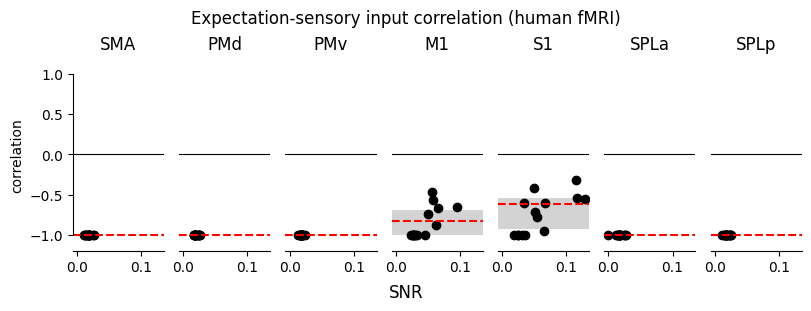

In [53]:
df_corr_bold = pd.read_csv(os.path.join(gl.baseDir, experiment2, gl.pcmDir, 'correlations.BOLD.tsv'), sep='\t')
corr = 'cue-finger'
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(8, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]
    df_corr_tmp = df_corr_bold[(df_corr_bold['roi'] == roi) & (df_corr_bold['Hem'] == H) & (df_corr_bold['corr'] == corr)]
    r_indiv = df_corr_tmp.r_indiv.to_numpy()
    SNR = df_corr_tmp.SNR.to_numpy()
    r_group = df_corr_tmp.r_group.to_numpy()[0]
    ci_lo, ci_hi = df_corr_tmp.ci_lo.to_numpy()[0], df_corr_tmp.ci_hi.to_numpy()[0]
    ax.scatter(SNR, r_indiv, color='k')
    ax.axhline(r_group, color='r', linestyle='--')
    ax.axhline(0, color='k', linestyle='-', lw=.8)
    ax.axhspan(ci_lo, ci_hi, lw=0, color='lightgrey', zorder=0)
    ax.set_ylim(-1.2, 1.2)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if r == 0:
        ax.spines[['left']].set_visible(True)
        ax.spines['left'].set_bounds(-1, 1)
    else:
        ax.tick_params(left=False)
    ax.set_title(roi)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Expectation-sensory input correlation (human fMRI)')

plt.show()


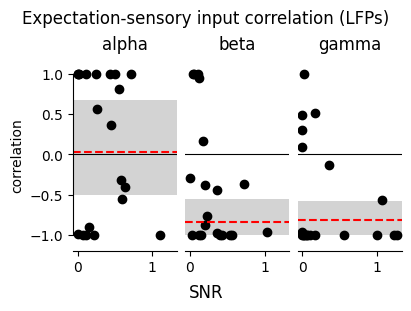

In [54]:
df_corr_lfp = pd.read_csv(os.path.join(gl.nhpDir, gl.pcmDir, 'correlations.lfp.tsv'), sep='\t')

fig, axs = plt.subplots(1, len(freqs), sharex=True, sharey=True, figsize=(4, 3), constrained_layout=True)

for f, freq in enumerate(freqs):
    ax = axs[f]
    df_corr_tmp = df_corr_lfp[(df_corr_lfp['freq'] == freq)]
    r_indiv = df_corr_tmp.r_indiv.to_numpy()
    SNR = df_corr_tmp.SNR.to_numpy()
    r_group = df_corr_tmp.r_group.to_numpy()[0]
    ci_lo, ci_hi = df_corr_tmp.ci_lo.to_numpy()[0], df_corr_tmp.ci_hi.to_numpy()[0]
    ax.scatter(SNR, r_indiv, color='k')
    ax.axhline(r_group, color='r', linestyle='--')
    ax.axhline(0, color='k', linestyle='-', lw=.8)
    ax.axhspan(ci_lo, ci_hi, lw=0, color='lightgrey', zorder=0)
    ax.set_ylim(-1.2, 1.2)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if f == 0:
        ax.spines[['left']].set_visible(True)
        ax.spines['left'].set_bounds(-1, 1)
    else:
        ax.tick_params(left=False)
    ax.set_title(freq)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Expectation-sensory input correlation (LFPs)')

plt.show()


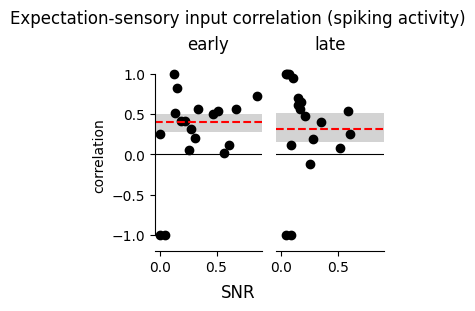

In [55]:
df_corr_spk = pd.read_csv(os.path.join(gl.nhpDir, gl.pcmDir, 'correlations.spk.tsv'), sep='\t')

fig, axs = plt.subplots(1, len(time_interval), sharex=True, sharey=True, figsize=(3, 3), constrained_layout=True)

for t, ti in enumerate(time_interval):
    ax = axs[t]
    df_corr_tmp = df_corr_spk[(df_corr_spk['time_interval'] == ti)]
    r_indiv = df_corr_tmp.r_indiv.to_numpy()
    SNR = df_corr_tmp.SNR.to_numpy()
    r_group = df_corr_tmp.r_group.to_numpy()[0]
    ci_lo, ci_hi = df_corr_tmp.ci_lo.to_numpy()[0], df_corr_tmp.ci_hi.to_numpy()[0]
    ax.scatter(SNR, r_indiv, color='k')
    ax.axhline(r_group, color='r', linestyle='--')
    ax.axhline(0, color='k', linestyle='-', lw=.8)
    ax.axhspan(ci_lo, ci_hi, lw=0, color='lightgrey', zorder=0)
    ax.set_ylim(-1.2, 1.2)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if t == 0:
        ax.spines[['left']].set_visible(True)
        ax.spines['left'].set_bounds(-1, 1)
    else:
        ax.tick_params(left=False)
    ax.set_title(ti)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Expectation-sensory input correlation (spiking activity)')

plt.show()
